# ConvPhysical Encoder Analysis: Particle Orbit Experiment

Interpretability and hypothesis testing for the `conv_physical` encoder on the particle orbit dataset.

**Dataset:** A blob of `num_blob` particles orbiting a circle (radius 3, $\omega$=0.05) embedded among `num_noise` pure random-walk noise particles. Observations are standardized, interleaved (x,y) coordinates sorted by x-position at t=0.

**Encoder:** `ConvPhysical` bins each timestep's particle coordinates onto a 2D occupancy grid and applies symmetric Conv2d filters in physical space. Learned filters are directly interpretable as spatial detectors — overlaying them with the blob's orbit path reveals whether CPIC has learned to attend to the coherent structure.

In [6]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

experiment_path = Path("../experiments/particle_orbit_experiment").resolve()
src_path = Path("../src").resolve()
for p in (experiment_path, src_path):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from generate_particle_orbit import generate_particle_orbit_process_timeseries
from filter_visualization import (
    plot_physical_filter_heatmaps,
    compute_orbit_in_grid_coords,
    compute_avg_density_grid,
    compute_tangential_arrows,
    plot_orbit_density_map,
    overlay_orbit_on_ax,
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from cpic import CPIC
from cpic.utils.data import PastFutureDataset

print(sys.executable)

/Users/phoenixpham/Desktop/CPIC_dev/.venv/bin/python3_cpic


In [7]:
device = "cuda:0" if torch.cuda.is_available() else "mps"
print("device:", device)

T = 10
period_steps = int(round((2 * 3.14159265) / 0.05))

conv_phys_base = {
    "deterministic": False,
    "encoder_type": "conv_physical",
    "linear_encoder": False,
    "n_layers": 0,
    "activation": "relu",
    "grid_size": 20,
    "spatial_bounds": 3.0,
    "conv_kernel_size": 3,
    "conv_stride": 1,
    "conv_padding": 1,
}

device: mps


In [8]:
import gc

def build_past_windows_and_gt(data, gt_latent, window_size, model, t_min=None, t_max=None):
    n_timesteps = len(data)
    t_min = window_size if t_min is None else max(window_size, int(t_min))
    t_max = n_timesteps if t_max is None else min(n_timesteps, int(t_max))
    end_times = np.arange(t_min, t_max)
    past_windows = np.stack([data[t - window_size : t] for t in end_times], axis=0)
    past_tensor = torch.from_numpy(past_windows).float().to(device)
    with torch.no_grad():
        z = model.encode(past_tensor)[:, -1, :].cpu().numpy()
    return z, gt_latent[end_times - 1]


def cleanup_model_resources(*objs, verbose=True):
    for obj in objs:
        del obj
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.synchronize(); torch.cuda.empty_cache(); torch.cuda.ipc_collect()
        if verbose:
            print(f"[cleanup] CUDA alloc={torch.cuda.memory_allocated()/1024**2:.1f}MB")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        if verbose: print("[cleanup] MPS backend active.")
    elif verbose:
        print("[cleanup] CPU backend active.")

## Hypothesis: blob count controls compression ease

**Claim:** More blob particles grouped together → more "votes" for the same coherent pattern → CPIC compresses that structure more easily, even with many noise particles present.

**Design:** Vary `num_blob` ∈ {5, 10, 20, 30, 50} with `num_noise=80` fixed. For each run:
- Train a fresh ConvPhysical (observation space) encoder.
- Evaluate a linear probe: **test $R^2$** for recovering blob centroid position.
- Compute a **filter–orbit alignment score**: fraction of each filter's weight mass that lands on the blob's orbit path on the grid.

If the hypothesis holds, both test $R^2$ and orbit alignment should increase with `num_blob`.

In [9]:
import torch.nn.functional as F

def orbit_filter_alignment(weights, orbit_grid, avg_density, grid_size):
    """
    Per-filter orbit selectivity: fraction of the filter's response on the density
    map that lands on the orbit path.

    Applies each |filter| as a spatial detector via conv2d on avg_density (20x20),
    then measures how much of the resulting response map overlaps the orbit path mask.
    Score > average means the filter responds more strongly on the orbit than off it.
    """
    orbit_mask = np.zeros((grid_size, grid_size), dtype=np.float32)
    oi = np.clip(orbit_grid[:, 1].astype(int), 0, grid_size - 1)
    oj = np.clip(orbit_grid[:, 0].astype(int), 0, grid_size - 1)
    orbit_mask[oi, oj] = 1.0
    orbit_mask_norm = orbit_mask / (orbit_mask.sum() + 1e-8)

    K = weights.shape[2]
    pad = K // 2
    density_t = torch.from_numpy(avg_density).float().unsqueeze(0).unsqueeze(0)  # (1,1,H,W)

    scores = []
    for c in range(weights.shape[0]):
        kernel = torch.from_numpy(np.abs(weights[c:c+1])).float()  # (1,1,K,K)
        response = F.conv2d(density_t, kernel, padding=pad).squeeze().numpy()  # (H,W)
        response_norm = response / (response.sum() + 1e-8)
        scores.append(float(np.sum(response_norm * orbit_mask_norm)))
    return np.array(scores)


def run_conv_physical_step(num_blob, num_noise, conv_phys_base, T, device,
                            t_max=2000, seed=42, predictive_space="observation"):
    """One sweep step: generate data, train ConvPhysical, probe, return metrics + artifacts."""
    d, gt, porder, plabels, smean, sstd, pos = generate_particle_orbit_process_timeseries(
        t_max=t_max, num_blob=num_blob, num_noise=num_noise,
        orbit_radius=3.0, omega=0.05, sigma_blob=0.1,
        noise_ar_coeff=0.8, spatial_bounds=10.0, seed=seed,
    )
    n_feat = d.shape[1]
    t_split = int(0.7 * len(d))
    train_ds = PastFutureDataset([d[:t_split]], window_size=T)

    cpic = CPIC(ydim=2, xdim=n_feat, T=T, encoder_params=conv_phys_base.copy(),
                hidden_dim=64, beta=1e-5, device=device, predictive_space=predictive_space)
    cpic.to(device)
    loss_, I_c_, I_p_ = cpic.fit(X=train_ds, epochs=80, batch_size=256, lr=2e-4, early_stop=20)

    z_tr, gt_tr = build_past_windows_and_gt(d, gt, T, cpic, t_min=T, t_max=t_split)
    z_te, gt_te = build_past_windows_and_gt(d, gt, T, cpic, t_min=t_split, t_max=len(d))
    reg = LinearRegression().fit(z_tr, gt_tr)
    r2_train = r2_score(gt_tr, reg.predict(z_tr))
    r2_test  = r2_score(gt_te, reg.predict(z_te))

    w, meta = cpic.encoder.get_filters(layer_idx=0)
    orbit_grid = compute_orbit_in_grid_coords(
        pos, plabels, porder, smean, sstd,
        grid_size=meta["grid_size"], spatial_bounds=meta["spatial_bounds"],
    )
    avg_density = compute_avg_density_grid(
        d[:t_split], grid_size=meta["grid_size"], spatial_bounds=meta["spatial_bounds"],
    )
    aligns = orbit_filter_alignment(w, orbit_grid, avg_density, meta["grid_size"])

    result = dict(
        num_blob=num_blob, num_noise=num_noise,
        r2_train=r2_train, r2_test=r2_test,
        filters=w.copy(), orbit_grid=orbit_grid, avg_density=avg_density,
        align_scores=aligns, max_align=float(aligns.max()), mean_align=float(aligns.mean()),
        meta=meta,
    )
    cleanup_model_resources(cpic, loss_, I_c_, I_p_)
    return result

In [10]:
num_blob_values = [5, 10, 20, 30, 50]
num_noise_fixed = 80

sweep_results = []
for nb_val in num_blob_values:
    print(f"\n--- num_blob={nb_val}, num_noise={num_noise_fixed} ---")
    res = run_conv_physical_step(
        num_blob=nb_val,
        num_noise=num_noise_fixed,
        conv_phys_base=conv_phys_base,
        T=T,
        device=device,
        predictive_space="observation",
    )
    print(f"  R² test={res['r2_test']:.3f}  max orbit-filter alignment={res['max_align']:.4f}")
    sweep_results.append(res)

print("\nSweep complete.")


--- num_blob=5, num_noise=80 ---


  1%|▏         | 1/80 [00:01<01:48,  1.38s/it]

Epoch 0: loss=0.0009, I_compress_bound=3.7249, I_predictive_bound=-0.0009


  2%|▎         | 2/80 [00:02<01:27,  1.12s/it]

Epoch 1: loss=-0.0034, I_compress_bound=5.3884, I_predictive_bound=0.0035


...

 99%|█████████▉| 79/80 [01:21<00:01,  1.04s/it]

Epoch 78: loss=-5.1761, I_compress_bound=5.3885, I_predictive_bound=5.1762


100%|██████████| 80/80 [01:22<00:00,  1.03s/it]

Epoch 79: loss=-5.1982, I_compress_bound=5.3885, I_predictive_bound=5.1983


[cleanup] MPS backend active.
  R² test=0.989  max orbit-filter alignment=0.0099

Sweep complete.


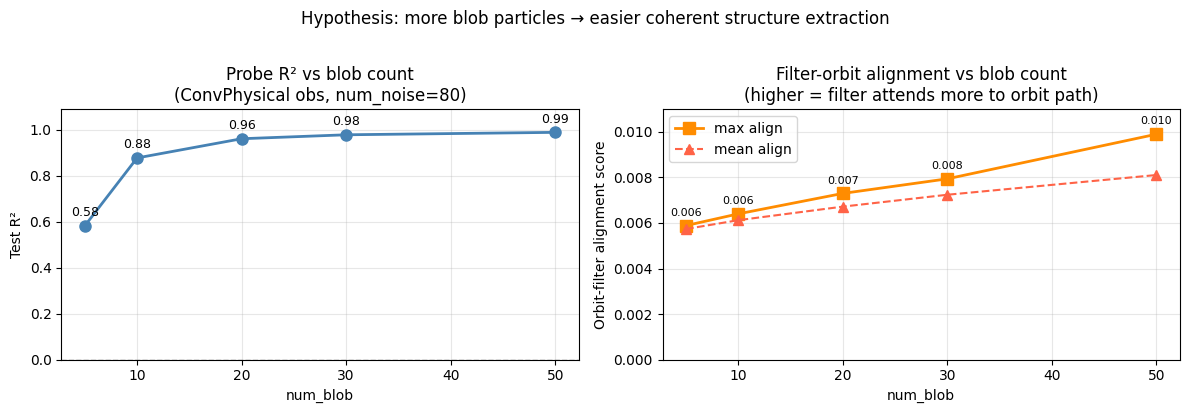

In [18]:
# Summary: R-squared and filter-orbit alignment vs num_blob
nb_vals     = [r["num_blob"]   for r in sweep_results]
r2_tests    = [r["r2_test"]   for r in sweep_results]
max_aligns  = [r["max_align"] for r in sweep_results]
mean_aligns = [r["mean_align"] for r in sweep_results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(nb_vals, r2_tests, "o-", color="steelblue", linewidth=2, markersize=8)
for x, y in zip(nb_vals, r2_tests):
    ax1.annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=9)
ax1.axhline(0, color="gray", linestyle="--", linewidth=1)
ax1.set_ylim(0, 1.09)
ax1.set_xlabel("num_blob")
ax1.set_ylabel("Test R²")
ax1.set_title(f"Probe R² vs blob count\n(ConvPhysical obs, num_noise={num_noise_fixed})")
ax1.grid(True, alpha=0.3)

ax2.plot(nb_vals, max_aligns,  "s-",  color="darkorange", linewidth=2, markersize=8, label="max align")
ax2.plot(nb_vals, mean_aligns, "^--", color="tomato",     linewidth=1.5, markersize=7, label="mean align")
for x, y in zip(nb_vals, max_aligns):
    ax2.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)
ax2.set_ylim(0, 0.011)
ax2.set_xlabel("num_blob")
ax2.set_ylabel("Orbit-filter alignment score")
ax2.set_title("Filter-orbit alignment vs blob count\n(higher = filter attends more to orbit path)")
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle("Hypothesis: more blob particles → easier coherent structure extraction", y=1.02)
fig.tight_layout()
plt.show()

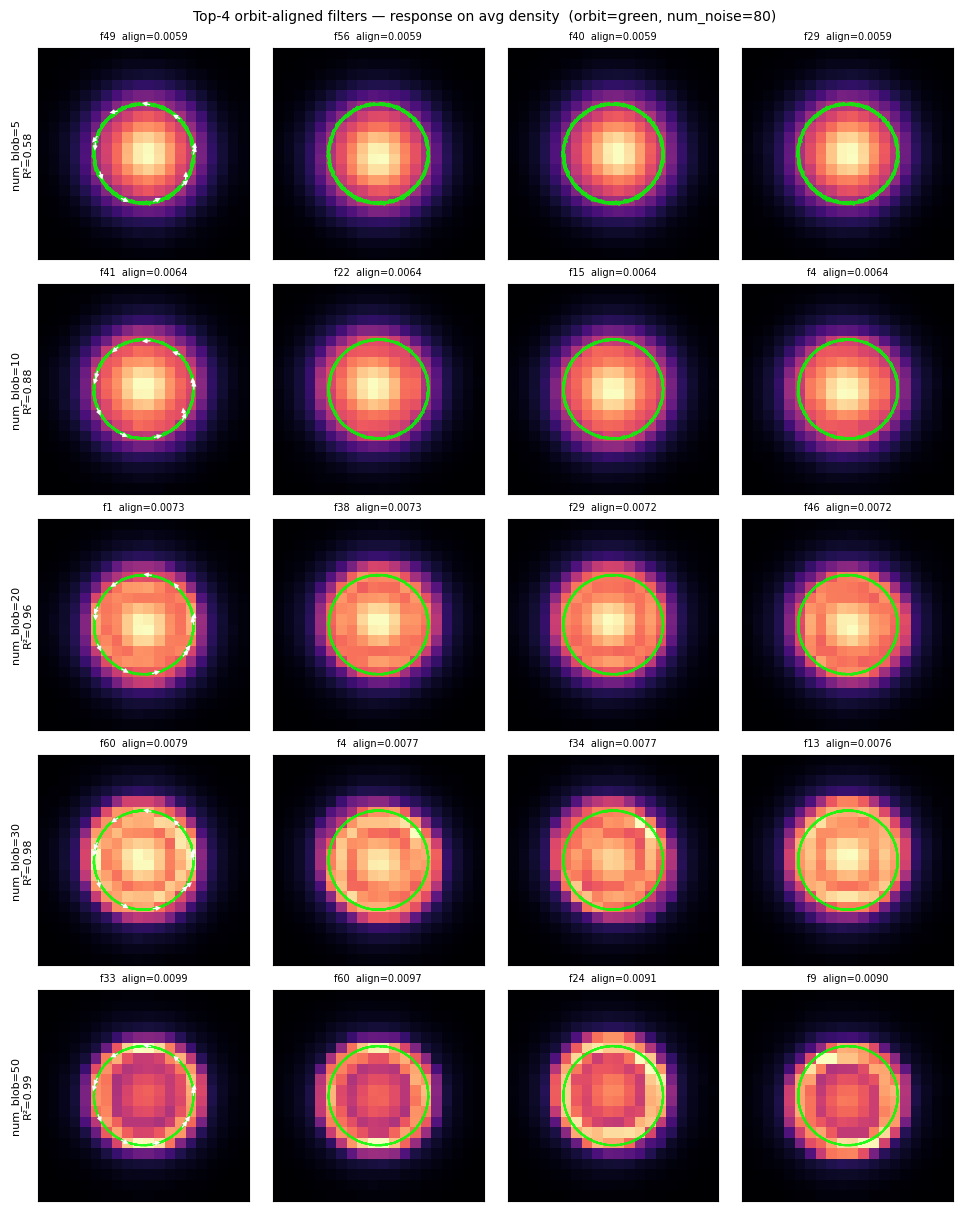

In [ ]:
# Filter grid: top-4 orbit-aligned filters per num_blob
# Shows each filter's RESPONSE MAP on avg_density (not the raw 3x3 kernel), so the orbit overlay and filter activations are in the same 20x20 coordinate space.
n_top  = 4
n_runs = len(sweep_results)

fig, axes = plt.subplots(n_runs, n_top, figsize=(n_top * 2.4, n_runs * 2.4), constrained_layout=True)
if n_runs == 1:
    axes = axes[np.newaxis, :]

for row, res in enumerate(sweep_results):
    w           = res["filters"]        # (C_out, 1, K, K)
    orbit_grid  = res["orbit_grid"]
    avg_density = res["avg_density"]
    aligns      = res["align_scores"]
    top_idx     = np.argsort(aligns)[::-1][:n_top]
    arrows      = compute_tangential_arrows(orbit_grid)

    density_t = torch.from_numpy(avg_density).float().unsqueeze(0).unsqueeze(0)
    K = w.shape[2]
    pad = K // 2

    for col, fi in enumerate(top_idx):
        kernel = torch.from_numpy(np.abs(w[fi:fi+1])).float()
        response = F.conv2d(density_t, kernel, padding=pad).squeeze().numpy()  # (20, 20)

        ax = axes[row, col]
        ax.imshow(response, cmap="magma", aspect="equal", origin="lower",
                  extent=[0, avg_density.shape[1], 0, avg_density.shape[0]])
        overlay_orbit_on_ax(ax, orbit_grid, arrows=arrows if col == 0 else None)
        ax.set_title(f"f{fi}  align={aligns[fi]:.4f}", fontsize=7)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        if col == 0:
            ax.set_ylabel(f"num_blob={res['num_blob']}\nR\u00b2={res['r2_test']:.2f}", fontsize=8)

fig.suptitle(
    f"Top-{n_top} orbit-aligned filters — response on avg density  "
    f"(orbit=green, num_noise={num_noise_fixed})",
    fontsize=10,
)
plt.show()

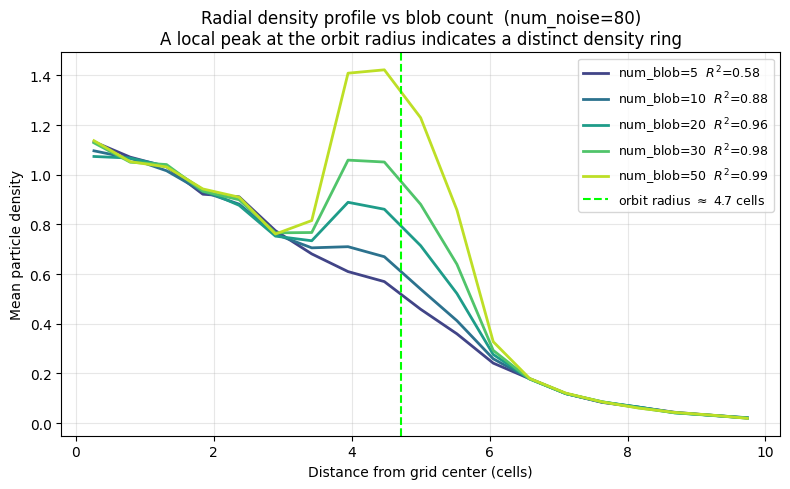

In [22]:
# Radial density profile: does the orbit ring sharpen with more blob particles?
# If hypothesis holds, a local peak should emerge at the orbit radius as num_blob increases.
fig, ax = plt.subplots(figsize=(8, 5))

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(sweep_results)))

for res, color in zip(sweep_results, colors):
    avg_density = res["avg_density"]
    grid_size   = res["meta"]["grid_size"]

    cx, cy = grid_size / 2.0, grid_size / 2.0
    ys, xs = np.mgrid[0:grid_size, 0:grid_size]
    r = np.sqrt((xs - cx) ** 2 + (ys - cy) ** 2)

    r_bins = np.linspace(0, grid_size / 2, 20)
    r_centers = 0.5 * (r_bins[:-1] + r_bins[1:])
    profile = np.array([
        avg_density[(r >= r_bins[i]) & (r < r_bins[i + 1])].mean()
        if np.any((r >= r_bins[i]) & (r < r_bins[i + 1])) else np.nan
        for i in range(len(r_bins) - 1)
    ])

    ax.plot(r_centers, profile, color=color, linewidth=2,
            label=f"num_blob={res['num_blob']}  $R^2$={res['r2_test']:.2f}")

# Orbit radius in grid coords (same for all runs)
grid_size = sweep_results[0]["meta"]["grid_size"]
center = np.array([grid_size / 2.0, grid_size / 2.0])
orbit_r_grid = np.linalg.norm(sweep_results[0]["orbit_grid"] - center, axis=1).mean()
ax.axvline(orbit_r_grid, color="lime", linestyle="--", linewidth=1.5,
           label=f"orbit radius $\\approx$ {orbit_r_grid:.1f} cells")

ax.set_xlabel("Distance from grid center (cells)")
ax.set_ylabel("Mean particle density")
ax.set_title(
    f"Radial density profile vs blob count  (num_noise={num_noise_fixed})\n"
    "A local peak at the orbit radius indicates a distinct density ring"
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Summary: hypothesis test results

**Hypothesis:** More blob particles grouped together → more "votes" for the same coherent pattern → CPIC compresses the orbit structure more easily, even with many noise particles present.

---

**Finding 1 — $R^2$ vs blob count (summary plot, left)**
The linear probe's test $R^2$ increases monotonically from 0.58 at `num_blob=5` to 0.99 at `num_blob=50`, with `num_noise=80` fixed throughout. This directly supports the hypothesis: CPIC's latent representation encodes the blob's orbital position increasingly well as the blob grows larger relative to the noise population.

**Finding 2 — Filter-orbit alignment vs blob count (summary plot, right)**
The orbit alignment score — measuring how much of each filter's response on the density map lands on the orbit path — rises from ~0.006 to ~0.010 across the sweep. The trend is consistent with the hypothesis but the absolute values are small and the differences are subtle, which points to a more nuanced mechanism (explained below).

**Finding 3 — Filter response maps**
The top-4 orbit-aligned filters all produce nearly identical Gaussian-blob response maps: bright at the grid center, falling off toward the edges, with the orbit circle sitting at the bright-to-dark boundary. The filters are not learning ring detectors. Rather, they act as local smoothers on the occupancy grid, and the ring's location at the boundary of the density falloff is what changes with blob count.

**Finding 4 — Radial density profile (the mechanistic explanation)**
This is the clearest result. With `num_blob=5`, the radial density profile is nearly flat at the orbit radius — the 5 blob particles contribute a ring too weak to distinguish from 80 noise particles. As `num_blob` grows, a sharp peak emerges at the orbit radius ($\approx$ 4.7 grid cells), becoming the dominant feature of the density field at `num_blob=50`. The $R^2$ values track this peak emergence almost exactly.

---

**Synthesis**

The hypothesis is confirmed, but the mechanism is more specific than "filters learn to detect the orbit." What actually happens:

> More blob particles → a stronger, sharper density ridge at the orbit radius in the 2D occupancy grid → a more reliable spatial feature for CPIC to compress → higher $R^2$ for orbit position recovery.

The improvement is driven by **input signal quality**, not filter specialization. The filters remain generic smoothers throughout; what changes is that the ring they are smoothing over becomes increasingly distinct from the noise floor. This is the physical meaning of "more votes for the same pattern": with few blob particles, their collective density signature is swamped by noise; with many, they carve out a clear ring that CPIC can track.